# **🚀 INTELLIGENT ENERGY SYSTEM (END-TO-END)🧠**

## **🏷️ Project Name**

**Intelligent Energy Operations System (IEOS)**

*AI + Engineering + Real-Time Decision Support*

---

# 🧩 SYSTEM ARCHITECTURE

```
Engineering System → Data → ML Models → Dashboard → Decisions
```

---

# **⚙️ 1. MACHINE LEARNING COMPONENTS**

## **🛢️ A. Upstream Model — Production Forecasting**

### **🎯 Goal:**

Predict oil production based on reservoir + operational conditions

### **📊 Inputs:**

* Reservoir pressure
* Choke size
* Gas-oil ratio
* Water cut
* CO₂ injection (EOR)

### **🤖 Model:**

* Random Forest Regressor

### **💡 Impact:**

* Optimize extraction strategy
* Predict decline trends
* Improve well performance

---

## **🚚 B. Midstream Model — Pipeline Blockage Risk**

### **🎯 Goal:**

Predict hydrate/blockage risk in pipelines

### **📊 Inputs:**

* Pressure
* Temperature
* Flow rate
* Water cut
* Inhibitor dosage

### **🤖 Model:**

* Random Forest Classifier

### **💡 Impact:**

* Prevent pipeline shutdowns
* Reduce maintenance cost
* Improve reliability

---

## **🏭 C. Downstream Model — Refinery Yield Optimization**

### **🎯 Goal:**

Predict refinery output efficiency

### **📊 Inputs:**

* API gravity
* Sulfur content
* Furnace temperature
* Catalyst activity

### **🤖 Model:**

* Random Forest Regressor

### **💡 Impact:**

* Increase product yield
* Reduce waste
* Improve profit margins

---

# **📊 2. DASHBOARD SYSTEM**

## **🖥️ Built with:**

👉 **Streamlit**

---

## **🔥 Dashboard Features**

### **📈 1. Real-Time KPIs**

* Production rate trends
* Hydrate risk %
* Average refinery yield

---

### **🚨 2. Risk Alerts**

User inputs:

* Pressure
* Temperature
* Flow rate

👉 Output:

* **HIGH RISK / LOW RISK**

💡 This mimics:
👉 Real industrial monitoring systems (SCADA / BMS / AWS dashboards)

---

### **⚙️ 3. Optimization Panel (DOWNSTREAM)**

User adjusts:

* Temperature
* Catalyst activity
* Reflux ratio

👉 Output:

* Predicted refinery yield

💡 This is:
👉 **Digital Twin concept (VERY HIGH VALUE)**

---

### **📉 4. Model Visualizations**

* Actual vs Predicted
* Feature importance



**A FULL ENGINEERING INTELLIGENCE SYSTEM**

### **🔥 It demonstrates:**

✔ Engineering knowledge

✔ Data science skills

✔ System thinking

✔ Business impact awareness

✔ Dashboard deployment


---

# **📈 4. BUSINESS IMPACT**

| Area       | Impact                            |
| ---------- | --------------------------------- |
| Upstream   | Better production planning        |
| Midstream  | Reduced downtime (millions saved) |
| Downstream | Increased yield & profitability   |
| Overall    | Data-driven engineering decisions |



Dataset shape: (1000, 6)


,reservoir_pressure,choke_size,gas_oil_ratio,water_cut,co2_injection_rate,oil_production_rate
0,2810.890416,24.886381,618.729094,0.554527,285.997939,174.388259
1,4827.500072,42.011245,595.166079,0.647511,402.716165,307.368932
2,4061.978796,57.901400,1650.007329,0.237851,380.080465,588.168033
3,3595.304695,51.146795,599.273920,0.518656,76.949952,411.449897
4,2046.065242,54.714935,635.119562,0.478809,74.624735,299.447899


Training set: (800, 5)
Testing set: (200, 5)

Model Performance:
MAE  : 42.84
RMSE : 55.28
R²   : 0.8355

Feature Importance:


,Feature,Importance
0,reservoir_pressure,0.379850
3,water_cut,0.328077
1,choke_size,0.229238
4,co2_injection_rate,0.036979
2,gas_oil_ratio,0.025856


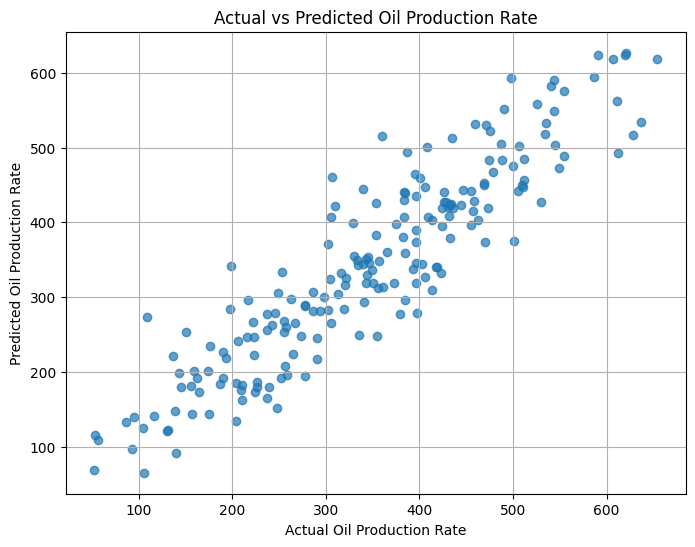

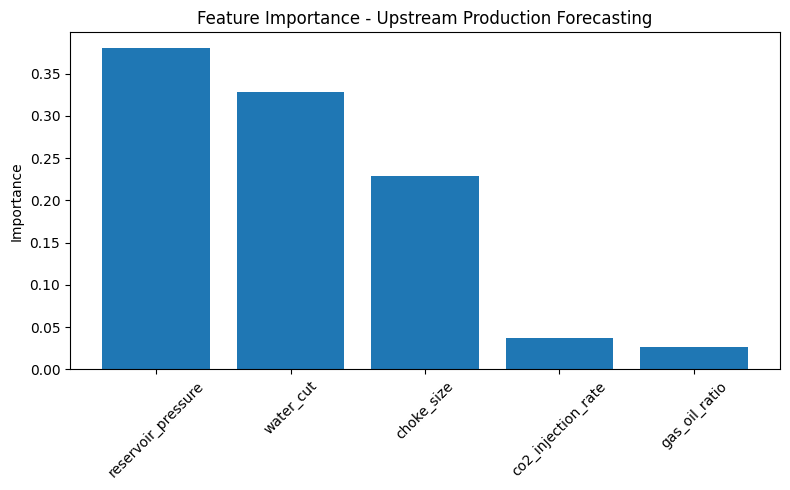


New Scenario Input:


,reservoir_pressure,choke_size,gas_oil_ratio,water_cut,co2_injection_rate
0,3200,40,900,0.22,180


Predicted Oil Production Rate: 398.33


In [1]:
# ============================================
# UPSTREAM MODEL — PRODUCTION FORECASTING
# Random Forest Regressor
# ============================================

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. SET RANDOM SEED
np.random.seed(42)

# 3. CREATE SYNTHETIC DATASET
# --------------------------------------------
# These features represent upstream operational
# and reservoir conditions affecting production.
# --------------------------------------------

n_samples = 1000

reservoir_pressure = np.random.uniform(1500, 5000, n_samples)      # psi
choke_size = np.random.uniform(16, 64, n_samples)                  # 1/64 inch units
gas_oil_ratio = np.random.uniform(200, 1800, n_samples)            # scf/STB
water_cut = np.random.uniform(0.05, 0.80, n_samples)               # fraction
co2_injection_rate = np.random.uniform(0, 500, n_samples)          # MSCF/day or arbitrary unit

# 4. GENERATE TARGET VARIABLE: OIL PRODUCTION RATE
# ------------------------------------------------
# This is a synthetic engineering-inspired formula.
# Higher pressure, choke size, GOR, and CO2 injection
# generally help production, while water cut reduces it.
# ------------------------------------------------

noise = np.random.normal(0, 50, n_samples)

oil_production_rate = (
    0.08 * reservoir_pressure
    + 4.5 * choke_size
    + 0.03 * gas_oil_ratio
    - 350 * water_cut
    + 0.15 * co2_injection_rate
    + noise
)

# Prevent unrealistic negative values
oil_production_rate = np.clip(oil_production_rate, a_min=50, a_max=None)

# 5. BUILD DATAFRAME
df = pd.DataFrame({
    "reservoir_pressure": reservoir_pressure,
    "choke_size": choke_size,
    "gas_oil_ratio": gas_oil_ratio,
    "water_cut": water_cut,
    "co2_injection_rate": co2_injection_rate,
    "oil_production_rate": oil_production_rate
})

print("Dataset shape:", df.shape)
display(df.head())

# 6. DEFINE FEATURES AND TARGET
X = df[[
    "reservoir_pressure",
    "choke_size",
    "gas_oil_ratio",
    "water_cut",
    "co2_injection_rate"
]]
y = df["oil_production_rate"]

# 7. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

# 8. TRAIN RANDOM FOREST REGRESSOR
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 9. MAKE PREDICTIONS
y_pred = model.predict(X_test)

# 10. EVALUATE MODEL
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# 11. FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
display(feature_importance)

# 12. PLOT: ACTUAL VS PREDICTED
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Oil Production Rate")
plt.ylabel("Predicted Oil Production Rate")
plt.title("Actual vs Predicted Oil Production Rate")
plt.grid(True)
plt.show()

# 13. PLOT: FEATURE IMPORTANCE
plt.figure(figsize=(8, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importance - Upstream Production Forecasting")
plt.tight_layout()
plt.show()

# 14. TEST WITH A NEW FIELD SCENARIO
new_data = pd.DataFrame({
    "reservoir_pressure": [3200],
    "choke_size": [40],
    "gas_oil_ratio": [900],
    "water_cut": [0.22],
    "co2_injection_rate": [180]
})

predicted_production = model.predict(new_data)[0]

print("\nNew Scenario Input:")
display(new_data)

print(f"Predicted Oil Production Rate: {predicted_production:.2f}")

The **Upstream Model — Production Forecasting** using a **Random Forest Regressor**.

It uses these inputs:

* reservoir pressure
* choke size
* gas-oil ratio
* water cut
* CO₂ injection rate

This version creates a **synthetic upstream dataset** so you can run it immediately in Colab, then train, evaluate, and test the model.

```python
# ============================================
# UPSTREAM MODEL — PRODUCTION FORECASTING
# Random Forest Regressor
# ============================================

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. SET RANDOM SEED
np.random.seed(42)

# 3. CREATE SYNTHETIC DATASET
# --------------------------------------------
# These features represent upstream operational
# and reservoir conditions affecting production.
# --------------------------------------------

n_samples = 1000

reservoir_pressure = np.random.uniform(1500, 5000, n_samples)      # psi
choke_size = np.random.uniform(16, 64, n_samples)                  # 1/64 inch units
gas_oil_ratio = np.random.uniform(200, 1800, n_samples)            # scf/STB
water_cut = np.random.uniform(0.05, 0.80, n_samples)               # fraction
co2_injection_rate = np.random.uniform(0, 500, n_samples)          # MSCF/day or arbitrary unit

# 4. GENERATE TARGET VARIABLE: OIL PRODUCTION RATE
# ------------------------------------------------
# This is a synthetic engineering-inspired formula.
# Higher pressure, choke size, GOR, and CO2 injection
# generally help production, while water cut reduces it.
# ------------------------------------------------

noise = np.random.normal(0, 50, n_samples)

oil_production_rate = (
    0.08 * reservoir_pressure
    + 4.5 * choke_size
    + 0.03 * gas_oil_ratio
    - 350 * water_cut
    + 0.15 * co2_injection_rate
    + noise
)

# Prevent unrealistic negative values
oil_production_rate = np.clip(oil_production_rate, a_min=50, a_max=None)

# 5. BUILD DATAFRAME
df = pd.DataFrame({
    "reservoir_pressure": reservoir_pressure,
    "choke_size": choke_size,
    "gas_oil_ratio": gas_oil_ratio,
    "water_cut": water_cut,
    "co2_injection_rate": co2_injection_rate,
    "oil_production_rate": oil_production_rate
})

print("Dataset shape:", df.shape)
display(df.head())

# 6. DEFINE FEATURES AND TARGET
X = df[[
    "reservoir_pressure",
    "choke_size",
    "gas_oil_ratio",
    "water_cut",
    "co2_injection_rate"
]]
y = df["oil_production_rate"]

# 7. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

# 8. TRAIN RANDOM FOREST REGRESSOR
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 9. MAKE PREDICTIONS
y_pred = model.predict(X_test)

# 10. EVALUATE MODEL
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# 11. FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
display(feature_importance)

# 12. PLOT: ACTUAL VS PREDICTED
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Oil Production Rate")
plt.ylabel("Predicted Oil Production Rate")
plt.title("Actual vs Predicted Oil Production Rate")
plt.grid(True)
plt.show()

# 13. PLOT: FEATURE IMPORTANCE
plt.figure(figsize=(8, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importance - Upstream Production Forecasting")
plt.tight_layout()
plt.show()

# 14. TEST WITH A NEW FIELD SCENARIO
new_data = pd.DataFrame({
    "reservoir_pressure": [3200],
    "choke_size": [40],
    "gas_oil_ratio": [900],
    "water_cut": [0.22],
    "co2_injection_rate": [180]
})

predicted_production = model.predict(new_data)[0]

print("\nNew Scenario Input:")
display(new_data)

print(f"Predicted Oil Production Rate: {predicted_production:.2f}")
```

### **What this code demonstrates**

This notebook shows how reservoir and operational conditions can be used to predict oil production. In practical terms, it supports:

* extraction strategy optimization
* decline trend awareness
* well performance improvement

### **Main concept behind the model**

The Random Forest Regressor learns nonlinear relationships between:

* pressure support
* well opening via choke size
* fluid behavior through gas-oil ratio
* production degradation through water cut
* enhanced recovery support through CO₂ injection

### **Overall Insights**

> Built an upstream production forecasting model using Random Forest Regression to estimate oil production from reservoir and operational variables, including pressure, choke size, gas-oil ratio, water cut, and CO₂ injection rate. The model supports production planning, extraction optimization, and well performance analysis.


##**The Midstream Model — Pipeline Blockage Risk using a Random Forest Classifier.**

It uses these inputs:

- pressure
- temperature
- flow rate
- water cut
- inhibitor dosage

**This version creates a synthetic midstream dataset so you can run it immediately, train the classifier, evaluate it, and test new pipeline scenarios.**

Dataset shape: (1200, 6)


,pressure,temperature,flow_rate,water_cut,inhibitor_dosage,blockage_risk
0,986.902155,80.661056,813.087500,0.121567,12.384603,0
1,1735.928598,21.966953,329.081400,0.460993,7.053564,1
2,1451.592124,21.769884,937.332011,0.156364,90.942950,0
3,1278.256029,45.888818,760.191491,0.230128,19.012877,1
4,702.824233,59.091455,1418.817152,0.182781,82.125015,0



Class distribution:
blockage_risk
0    944
1    256
Name: count, dtype: int64

Training set: (960, 5)
Testing set : (240, 5)

Model Performance:
Accuracy : 0.9500
Precision: 1.0000
Recall   : 0.7647
F1 Score : 0.8667

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       189
           1       1.00      0.76      0.87        51

    accuracy                           0.95       240
   macro avg       0.97      0.88      0.92       240
weighted avg       0.95      0.95      0.95       240


Feature Importance:


,Feature,Importance
0,pressure,0.275125
1,temperature,0.257908
4,inhibitor_dosage,0.230771
2,flow_rate,0.129918
3,water_cut,0.106278


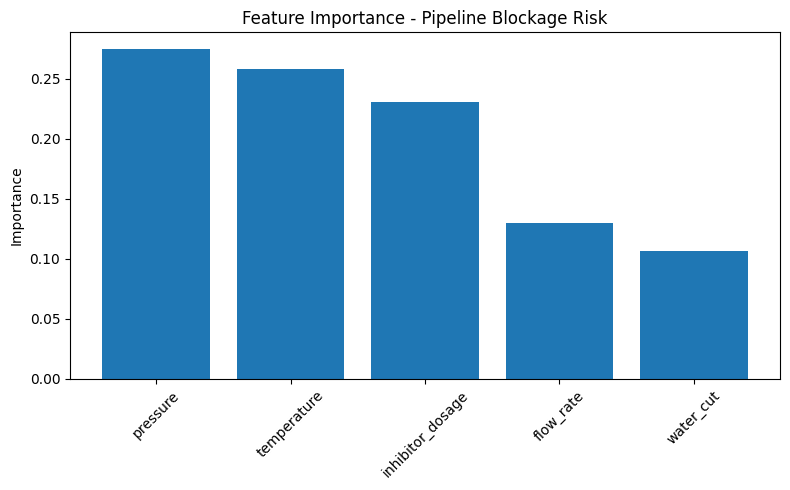

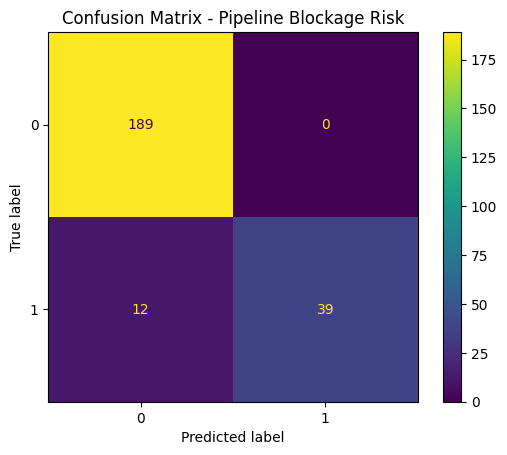


New Scenario Input:


,pressure,temperature,flow_rate,water_cut,inhibitor_dosage
0,1450,35,1500,0.35,10


Predicted Blockage Risk Class: HIGH
Predicted Probability of High Risk: 0.9550


In [2]:
# ============================================
# MIDSTREAM MODEL — PIPELINE BLOCKAGE RISK
# Random Forest Classifier
# ============================================

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# 2. SET RANDOM SEED
np.random.seed(42)

# 3. CREATE SYNTHETIC DATASET
# --------------------------------------------
# These variables represent pipeline operating
# conditions that influence hydrate/blockage risk.
# --------------------------------------------

n_samples = 1200

pressure = np.random.uniform(500, 1800, n_samples)          # psi
temperature = np.random.uniform(20, 100, n_samples)         # deg F
flow_rate = np.random.uniform(200, 2000, n_samples)         # bbl/day or arbitrary unit
water_cut = np.random.uniform(0.01, 0.80, n_samples)        # fraction
inhibitor_dosage = np.random.uniform(0, 100, n_samples)     # ppm or arbitrary unit

# 4. GENERATE TARGET VARIABLE: BLOCKAGE RISK
# ------------------------------------------------
# Engineering-inspired logic:
# - Higher pressure can increase hydrate tendency
# - Lower temperature raises hydrate risk
# - Higher flow and water content can increase instability
# - More inhibitor lowers the risk
# ------------------------------------------------

risk_score = (
    0.004 * pressure
    - 0.06 * temperature
    + 0.0015 * flow_rate
    + 2.5 * water_cut
    - 0.04 * inhibitor_dosage
    + np.random.normal(0, 0.6, n_samples)
)

# Convert score to binary class
# 1 = High blockage risk
# 0 = Low blockage risk
blockage_risk = (risk_score > 3.8).astype(int)

# 5. BUILD DATAFRAME
df = pd.DataFrame({
    "pressure": pressure,
    "temperature": temperature,
    "flow_rate": flow_rate,
    "water_cut": water_cut,
    "inhibitor_dosage": inhibitor_dosage,
    "blockage_risk": blockage_risk
})

print("Dataset shape:", df.shape)
display(df.head())

print("\nClass distribution:")
print(df["blockage_risk"].value_counts())

# 6. DEFINE FEATURES AND TARGET
X = df[[
    "pressure",
    "temperature",
    "flow_rate",
    "water_cut",
    "inhibitor_dosage"
]]
y = df["blockage_risk"]

# 7. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining set:", X_train.shape)
print("Testing set :", X_test.shape)

# 8. TRAIN RANDOM FOREST CLASSIFIER
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 9. MAKE PREDICTIONS
y_pred = model.predict(X_test)

# Optional probability output
y_prob = model.predict_proba(X_test)[:, 1]

# 10. EVALUATE MODEL
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 11. FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
display(feature_importance)

# 12. PLOT: FEATURE IMPORTANCE
plt.figure(figsize=(8, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importance - Pipeline Blockage Risk")
plt.tight_layout()
plt.show()

# 13. PLOT: CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Pipeline Blockage Risk")
plt.show()

# 14. TEST WITH A NEW PIPELINE SCENARIO
new_data = pd.DataFrame({
    "pressure": [1450],
    "temperature": [35],
    "flow_rate": [1500],
    "water_cut": [0.35],
    "inhibitor_dosage": [10]
})

predicted_class = model.predict(new_data)[0]
predicted_probability = model.predict_proba(new_data)[0, 1]

print("\nNew Scenario Input:")
display(new_data)

print(f"Predicted Blockage Risk Class: {'HIGH' if predicted_class == 1 else 'LOW'}")
print(f"Predicted Probability of High Risk: {predicted_probability:.4f}")

The **Midstream Model — Pipeline Blockage Risk** using a **Random Forest Classifier**.

It uses these inputs:

* pressure
* temperature
* flow rate
* water cut
* inhibitor dosage

This version creates a **synthetic midstream dataset** so you can run it immediately in Colab, train the classifier, evaluate it, and test new pipeline scenarios.

```python
# ============================================
# MIDSTREAM MODEL — PIPELINE BLOCKAGE RISK
# Random Forest Classifier
# Google Colab Ready
# ============================================

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# 2. SET RANDOM SEED
np.random.seed(42)

# 3. CREATE SYNTHETIC DATASET
# --------------------------------------------
# These variables represent pipeline operating
# conditions that influence hydrate/blockage risk.
# --------------------------------------------

n_samples = 1200

pressure = np.random.uniform(500, 1800, n_samples)          # psi
temperature = np.random.uniform(20, 100, n_samples)         # deg F
flow_rate = np.random.uniform(200, 2000, n_samples)         # bbl/day or arbitrary unit
water_cut = np.random.uniform(0.01, 0.80, n_samples)        # fraction
inhibitor_dosage = np.random.uniform(0, 100, n_samples)     # ppm or arbitrary unit

# 4. GENERATE TARGET VARIABLE: BLOCKAGE RISK
# ------------------------------------------------
# Engineering-inspired logic:
# - Higher pressure can increase hydrate tendency
# - Lower temperature raises hydrate risk
# - Higher flow and water content can increase instability
# - More inhibitor lowers the risk
# ------------------------------------------------

risk_score = (
    0.004 * pressure
    - 0.06 * temperature
    + 0.0015 * flow_rate
    + 2.5 * water_cut
    - 0.04 * inhibitor_dosage
    + np.random.normal(0, 0.6, n_samples)
)

# Convert score to binary class
# 1 = High blockage risk
# 0 = Low blockage risk
blockage_risk = (risk_score > 3.8).astype(int)

# 5. BUILD DATAFRAME
df = pd.DataFrame({
    "pressure": pressure,
    "temperature": temperature,
    "flow_rate": flow_rate,
    "water_cut": water_cut,
    "inhibitor_dosage": inhibitor_dosage,
    "blockage_risk": blockage_risk
})

print("Dataset shape:", df.shape)
display(df.head())

print("\nClass distribution:")
print(df["blockage_risk"].value_counts())

# 6. DEFINE FEATURES AND TARGET
X = df[[
    "pressure",
    "temperature",
    "flow_rate",
    "water_cut",
    "inhibitor_dosage"
]]
y = df["blockage_risk"]

# 7. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining set:", X_train.shape)
print("Testing set :", X_test.shape)

# 8. TRAIN RANDOM FOREST CLASSIFIER
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 9. MAKE PREDICTIONS
y_pred = model.predict(X_test)

# Optional probability output
y_prob = model.predict_proba(X_test)[:, 1]

# 10. EVALUATE MODEL
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 11. FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
display(feature_importance)

# 12. PLOT: FEATURE IMPORTANCE
plt.figure(figsize=(8, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importance - Pipeline Blockage Risk")
plt.tight_layout()
plt.show()

# 13. PLOT: CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Pipeline Blockage Risk")
plt.show()

# 14. TEST WITH A NEW PIPELINE SCENARIO
new_data = pd.DataFrame({
    "pressure": [1450],
    "temperature": [35],
    "flow_rate": [1500],
    "water_cut": [0.35],
    "inhibitor_dosage": [10]
})

predicted_class = model.predict(new_data)[0]
predicted_probability = model.predict_proba(new_data)[0, 1]

print("\nNew Scenario Input:")
display(new_data)

print(f"Predicted Blockage Risk Class: {'HIGH' if predicted_class == 1 else 'LOW'}")
print(f"Predicted Probability of High Risk: {predicted_probability:.4f}")
```

### **What this code demonstrates**

This notebook shows how pipeline operating conditions can be used to classify hydrate or blockage risk. In practical terms, it supports:

* early warning for shutdown risk
* maintenance planning
* flow assurance reliability

### **Main concept behind the model**

The Random Forest Classifier learns nonlinear relationships between:

* **pressure**, which can contribute to hydrate formation
* **temperature**, where lower values often raise hydrate risk
* **flow rate**, which affects transport behavior
* **water cut**, which increases blockage susceptibility
* **inhibitor dosage**, which helps suppress hydrate formation

### **Good way to explain it**

> Built a **midstream pipeline blockage risk classifier** using Random Forest to predict hydrate-related disruption risk from pressure, temperature, flow rate, water cut, and inhibitor dosage.

The model supports proactive risk detection, maintenance reduction, and improved pipeline reliability.

A useful engineering framing line for the notebook is:


**Hydrate Risk = f(P, T, Q, WC, ID)**


where:

* (P) = pressure
* (T) = temperature
* (Q) = flow rate
* (WC) = water cut
* (ID) = inhibitor dosage

**This expresses that blockage risk is a function of thermodynamic and operating conditions.**


###**The Downstream Model — Refinery Yield Optimization using a Random Forest Regressor.**

It uses these inputs:

- API gravity
- sulfur content
- furnace temperature
- catalyst activity

This version creates a synthetic downstream dataset so you can run it to train the model, evaluate it, and test **new refinery conditions**.

Dataset shape: (1200, 5)


,api_gravity,sulfur_content,furnace_temperature,catalyst_activity,refinery_yield
0,28.112583,3.815490,351.090625,57.061177,91.947524
1,43.669286,0.220476,310.756783,78.543871,98.000000
2,37.763836,0.208405,361.444334,59.263518,98.000000
3,34.163779,1.685690,346.682624,63.932153,98.000000
4,22.212503,2.494352,401.568096,60.935490,96.341208


Training set: (960, 4)
Testing set: (240, 4)

Model Performance:
MAE  : 0.80
RMSE : 1.60
R²   : 0.7937

Feature Importance:


,Feature,Importance
3,catalyst_activity,0.314465
1,sulfur_content,0.282831
0,api_gravity,0.280887
2,furnace_temperature,0.121817


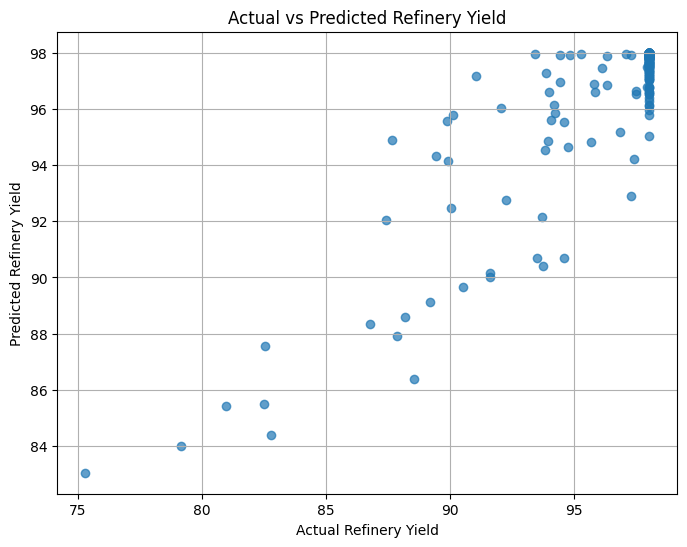

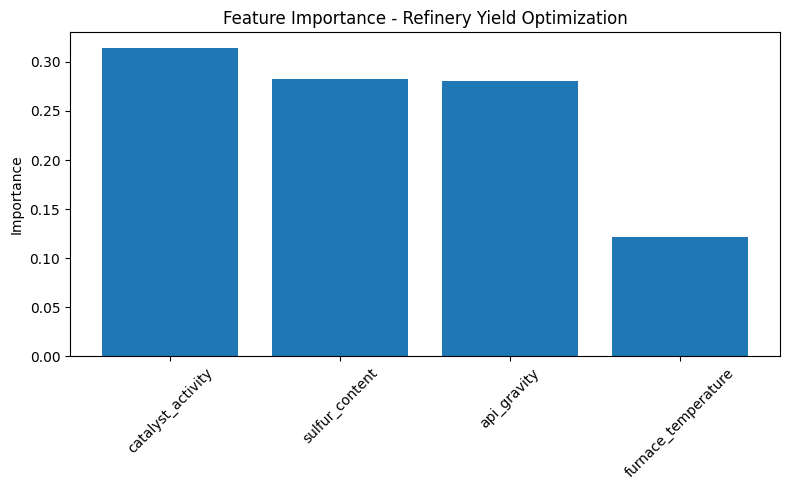


New Scenario Input:


,api_gravity,sulfur_content,furnace_temperature,catalyst_activity
0,34.5,1.2,385,88


Predicted Refinery Yield: 98.00%


In [3]:
# ============================================
# DOWNSTREAM MODEL — REFINERY YIELD OPTIMIZATION
# Random Forest Regressor
# ============================================

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. SET RANDOM SEED
np.random.seed(42)

# 3. CREATE SYNTHETIC DATASET
# --------------------------------------------
# These variables represent crude quality and
# refinery operating conditions that influence yield.
# --------------------------------------------

n_samples = 1200

api_gravity = np.random.uniform(18, 45, n_samples)            # degrees API
sulfur_content = np.random.uniform(0.1, 5.0, n_samples)       # wt%
furnace_temperature = np.random.uniform(300, 450, n_samples)  # deg C
catalyst_activity = np.random.uniform(50, 100, n_samples)     # %

# 4. GENERATE TARGET VARIABLE: REFINERY YIELD
# ------------------------------------------------
# Engineering-inspired logic:
# - Higher API gravity often improves valuable product recovery
# - Higher sulfur generally reduces efficiency
# - Higher furnace temperature can improve conversion to a point
# - Higher catalyst activity improves reaction performance
# ------------------------------------------------

noise = np.random.normal(0, 2.5, n_samples)

refinery_yield = (
    35
    + 0.9 * api_gravity
    - 3.5 * sulfur_content
    + 0.07 * furnace_temperature
    + 0.35 * catalyst_activity
    + noise
)

# Keep values realistic
refinery_yield = np.clip(refinery_yield, a_min=40, a_max=98)

# 5. BUILD DATAFRAME
df = pd.DataFrame({
    "api_gravity": api_gravity,
    "sulfur_content": sulfur_content,
    "furnace_temperature": furnace_temperature,
    "catalyst_activity": catalyst_activity,
    "refinery_yield": refinery_yield
})

print("Dataset shape:", df.shape)
display(df.head())

# 6. DEFINE FEATURES AND TARGET
X = df[[
    "api_gravity",
    "sulfur_content",
    "furnace_temperature",
    "catalyst_activity"
]]
y = df["refinery_yield"]

# 7. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

# 8. TRAIN RANDOM FOREST REGRESSOR
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 9. MAKE PREDICTIONS
y_pred = model.predict(X_test)

# 10. EVALUATE MODEL
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# 11. FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
display(feature_importance)

# 12. PLOT: ACTUAL VS PREDICTED
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Refinery Yield")
plt.ylabel("Predicted Refinery Yield")
plt.title("Actual vs Predicted Refinery Yield")
plt.grid(True)
plt.show()

# 13. PLOT: FEATURE IMPORTANCE
plt.figure(figsize=(8, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importance - Refinery Yield Optimization")
plt.tight_layout()
plt.show()

# 14. TEST WITH A NEW REFINERY SCENARIO
new_data = pd.DataFrame({
    "api_gravity": [34.5],
    "sulfur_content": [1.2],
    "furnace_temperature": [385],
    "catalyst_activity": [88]
})

predicted_yield = model.predict(new_data)[0]

print("\nNew Scenario Input:")
display(new_data)

print(f"Predicted Refinery Yield: {predicted_yield:.2f}%")

The **Downstream Model — Refinery Yield Optimization** using a **Random Forest Regressor**.

It uses these inputs:

* API gravity
* sulfur content
* furnace temperature
* catalyst activity

This version creates a **synthetic downstream dataset** so you can run it immediately in Colab, train the model, evaluate it, and test new refinery conditions.

```python
# ============================================
# DOWNSTREAM MODEL — REFINERY YIELD OPTIMIZATION
# Random Forest Regressor
# ============================================

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. SET RANDOM SEED
np.random.seed(42)

# 3. CREATE SYNTHETIC DATASET
# --------------------------------------------
# These variables represent crude quality and
# refinery operating conditions that influence yield.
# --------------------------------------------

n_samples = 1200

api_gravity = np.random.uniform(18, 45, n_samples)            # degrees API
sulfur_content = np.random.uniform(0.1, 5.0, n_samples)       # wt%
furnace_temperature = np.random.uniform(300, 450, n_samples)  # deg C
catalyst_activity = np.random.uniform(50, 100, n_samples)     # %

# 4. GENERATE TARGET VARIABLE: REFINERY YIELD
# ------------------------------------------------
# Engineering-inspired logic:
# - Higher API gravity often improves valuable product recovery
# - Higher sulfur generally reduces efficiency
# - Higher furnace temperature can improve conversion to a point
# - Higher catalyst activity improves reaction performance
# ------------------------------------------------

noise = np.random.normal(0, 2.5, n_samples)

refinery_yield = (
    35
    + 0.9 * api_gravity
    - 3.5 * sulfur_content
    + 0.07 * furnace_temperature
    + 0.35 * catalyst_activity
    + noise
)

# Keep values realistic
refinery_yield = np.clip(refinery_yield, a_min=40, a_max=98)

# 5. BUILD DATAFRAME
df = pd.DataFrame({
    "api_gravity": api_gravity,
    "sulfur_content": sulfur_content,
    "furnace_temperature": furnace_temperature,
    "catalyst_activity": catalyst_activity,
    "refinery_yield": refinery_yield
})

print("Dataset shape:", df.shape)
display(df.head())

# 6. DEFINE FEATURES AND TARGET
X = df[[
    "api_gravity",
    "sulfur_content",
    "furnace_temperature",
    "catalyst_activity"
]]
y = df["refinery_yield"]

# 7. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

# 8. TRAIN RANDOM FOREST REGRESSOR
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 9. MAKE PREDICTIONS
y_pred = model.predict(X_test)

# 10. EVALUATE MODEL
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# 11. FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
display(feature_importance)

# 12. PLOT: ACTUAL VS PREDICTED
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Refinery Yield")
plt.ylabel("Predicted Refinery Yield")
plt.title("Actual vs Predicted Refinery Yield")
plt.grid(True)
plt.show()

# 13. PLOT: FEATURE IMPORTANCE
plt.figure(figsize=(8, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importance - Refinery Yield Optimization")
plt.tight_layout()
plt.show()

# 14. TEST WITH A NEW REFINERY SCENARIO
new_data = pd.DataFrame({
    "api_gravity": [34.5],
    "sulfur_content": [1.2],
    "furnace_temperature": [385],
    "catalyst_activity": [88]
})

predicted_yield = model.predict(new_data)[0]

print("\nNew Scenario Input:")
display(new_data)

print(f"Predicted Refinery Yield: {predicted_yield:.2f}%")
```

### What this code demonstrates

This notebook shows how crude quality and operating conditions can be used to predict refinery output efficiency. In practical terms, it supports:

* yield improvement
* process efficiency
* margin optimization
* waste reduction

### Main concept behind the model

The Random Forest Regressor learns nonlinear relationships between:

* **API gravity**, which influences product value and conversion behavior
* **sulfur content**, which can reduce process efficiency and increase treatment needs
* **furnace temperature**, which affects thermal conversion
* **catalyst activity**, which drives reaction performance

### ** Insights and explaination**


> Built a downstream refinery yield optimization model using Random Forest Regression to predict output efficiency from crude quality and process variables, including API gravity, sulfur content, furnace temperature, and catalyst activity. The model supports yield improvement, waste reduction, and profitability-focused process optimization.

A useful engineering framing line for the notebook is:

**Y = f(API, S, T, C)**

where:

* (Y) = refinery yield
* (API) = API gravity
* (S) = sulfur content
* (T) = furnace temperature
* (C) = catalyst activity

**This expresses that refinery yield is a function of crude characteristics and operating conditions.**

Dataset shape: (1200, 5)


,api_gravity,sulfur_content,furnace_temperature,catalyst_activity,refinery_yield
0,28.112583,3.815490,351.090625,57.061177,91.947524
1,43.669286,0.220476,310.756783,78.543871,98.000000
2,37.763836,0.208405,361.444334,59.263518,98.000000
3,34.163779,1.685690,346.682624,63.932153,98.000000
4,22.212503,2.494352,401.568096,60.935490,96.341208


Training set: (960, 4)
Testing set: (240, 4)

Model Performance:
MAE  : 0.80
RMSE : 1.60
R²   : 0.7937

Feature Importance:


,Feature,Importance
3,catalyst_activity,0.314465
1,sulfur_content,0.282831
0,api_gravity,0.280887
2,furnace_temperature,0.121817


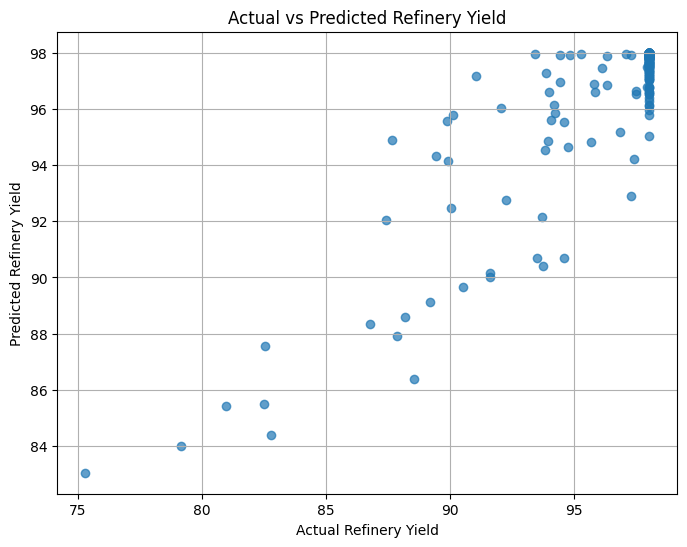

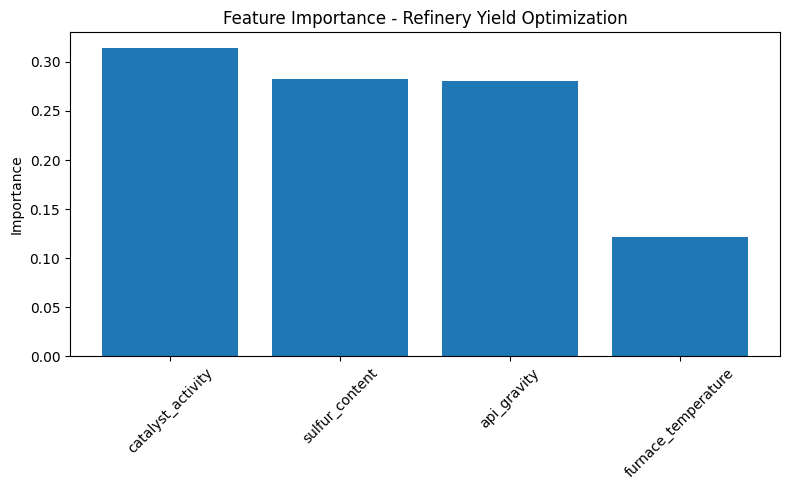


New Scenario Input:


,api_gravity,sulfur_content,furnace_temperature,catalyst_activity
0,34.5,1.2,385,88


Predicted Refinery Yield: 98.00%


In [5]:
# ============================================
# DOWNSTREAM MODEL — REFINERY YIELD OPTIMIZATION
# Random Forest Regressor
# ============================================

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. SET RANDOM SEED
np.random.seed(42)

# 3. CREATE SYNTHETIC DATASET
# --------------------------------------------
# These variables represent crude quality and
# refinery operating conditions that influence yield.
# --------------------------------------------

n_samples = 1200

api_gravity = np.random.uniform(18, 45, n_samples)            # degrees API
sulfur_content = np.random.uniform(0.1, 5.0, n_samples)       # wt%
furnace_temperature = np.random.uniform(300, 450, n_samples)  # deg C
catalyst_activity = np.random.uniform(50, 100, n_samples)     # %

# 4. GENERATE TARGET VARIABLE: REFINERY YIELD
# ------------------------------------------------
# Engineering-inspired logic:
# - Higher API gravity often improves valuable product recovery
# - Higher sulfur generally reduces efficiency
# - Higher furnace temperature can improve conversion to a point
# - Higher catalyst activity improves reaction performance
# ------------------------------------------------

noise = np.random.normal(0, 2.5, n_samples)

refinery_yield = (
    35
    + 0.9 * api_gravity
    - 3.5 * sulfur_content
    + 0.07 * furnace_temperature
    + 0.35 * catalyst_activity
    + noise
)

# Keep values realistic
refinery_yield = np.clip(refinery_yield, a_min=40, a_max=98)

# 5. BUILD DATAFRAME
df = pd.DataFrame({
    "api_gravity": api_gravity,
    "sulfur_content": sulfur_content,
    "furnace_temperature": furnace_temperature,
    "catalyst_activity": catalyst_activity,
    "refinery_yield": refinery_yield
})

print("Dataset shape:", df.shape)
display(df.head())

# 6. DEFINE FEATURES AND TARGET
X = df[[
    "api_gravity",
    "sulfur_content",
    "furnace_temperature",
    "catalyst_activity"
]]
y = df["refinery_yield"]

# 7. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

# 8. TRAIN RANDOM FOREST REGRESSOR
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 9. MAKE PREDICTIONS
y_pred = model.predict(X_test)

# 10. EVALUATE MODEL
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# 11. FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
display(feature_importance)

# 12. PLOT: ACTUAL VS PREDICTED
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Refinery Yield")
plt.ylabel("Predicted Refinery Yield")
plt.title("Actual vs Predicted Refinery Yield")
plt.grid(True)
plt.show()

# 13. PLOT: FEATURE IMPORTANCE
plt.figure(figsize=(8, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importance - Refinery Yield Optimization")
plt.tight_layout()
plt.show()

# 14. TEST WITH A NEW REFINERY SCENARIO
new_data = pd.DataFrame({
    "api_gravity": [34.5],
    "sulfur_content": [1.2],
    "furnace_temperature": [385],
    "catalyst_activity": [88]
})

predicted_yield = model.predict(new_data)[0]

print("\nNew Scenario Input:")
display(new_data)

print(f"Predicted Refinery Yield: {predicted_yield:.2f}%")

**What this code demonstrates**

This notebook shows how crude quality and operating conditions can be used to predict refinery output efficiency. In practical terms, it supports:

- yield improvement
- process efficiency
- margin optimization
- waste reduction
- Main concept behind the model

**The Random Forest Regressor learns nonlinear relationships between:**

API gravity, which influences product value and conversion behavior
sulfur content, which can reduce process efficiency and increase treatment needs
furnace temperature, which affects thermal conversion
catalyst activity, which drives reaction performance

** Insights and explaination**

Built a downstream refinery yield optimization model using Random Forest Regression to predict output efficiency from crude quality and process variables, including API gravity, sulfur content, furnace temperature, and catalyst activity. The model supports yield improvement, waste reduction, and profitability-focused process optimization.

A useful engineering framing line for the notebook is:

**Y = f(API, S, T, C)**

where:

- (Y) = refinery yield

- (API) = API gravity

- (S) = sulfur content

- (T) = furnace temperature

- (C) = catalyst activity

**This expresses that refinery yield is a function of crude characteristics and operating conditions.**

**This concludes the first part A,B,and C**

**📊 2. DASHBOARD SYSTEM will be built next**